In [3]:
!pip install mne hu-neuro-pipeline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mne import set_bipolar_reference
from mne.io import read_raw
from mne.preprocessing import ICA
from pipeline.datasets import get_erpcore
from mne import (Epochs, events_from_annotations, merge_events)
from mne.viz import plot_compare_evokeds

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 31.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.9/101.9 kB 8.2 MB/s eta 0:00:00


#con n=2 y epocas de 4s

In [ ]:
#genero las listas donde guardo las variables y1, y1err, y2, y2err, y3, y3err de todos los sujetos
#para luego hacer el promedio y prop el error
#estas variables corresponden a las target words. 1-related. 2-unrelated. 3-resta.
y1_list=[]
y1err_list=[]
y2_list=[]
y2err_list=[]
y3_list=[]
y3err_list=[]
y4_list=[] #para la normalizacion

theta_rel = []
theta_unrel = []

freqs = np.logspace(*np.log10([1, 30]), num=20)

sujetos = [f'sub-{i:03d}' for i in range(1, 41)]

for i in range(1,16): #excluyo el 1 (empieza en 0)
    #importe de datos
    files_dict = get_erpcore('N400', participants=sujetos[i], path='data')

    raw_file = files_dict['raw_files'][0]
    raw = read_raw(raw_file, preload=True)
    raw.get_data()

    raw = set_bipolar_reference(raw, anode='FP1', cathode='VEOG_lower', ch_name='VEOG', drop_refs=False)
    raw = set_bipolar_reference(raw, anode='HEOG_right', cathode='HEOG_left', ch_name='HEOG', drop_refs=False)
    raw = raw.set_channel_types({'VEOG': 'eog', 'HEOG': 'eog'})
    raw = raw.drop_channels(['VEOG_lower', 'HEOG_right', 'HEOG_left'])

    raw = raw.set_montage('biosemi64', match_case=False)

    #pre-procesado
    raw = raw.filter(l_freq=1, h_freq=40) ###

    ica = ICA(n_components=15)
    ica = ica.fit(raw)
    eog_indices, eog_scores = ica.find_bads_eog(raw, ch_name=['HEOG', 'VEOG'], verbose=False)
    ica.exclude = eog_indices
    raw = ica.apply(raw)

    raw = raw.set_eeg_reference('average')

    #eventos y épocas
    events, event_id = events_from_annotations(raw)
    events = merge_events(events, ids=[1, 2],new_id=1)
    events = merge_events(events, ids=[3, 4],new_id=2)
    events = merge_events(events, ids=[7, 8],new_id=3)
    events = merge_events(events, ids=[9, 10],new_id=4)
    event_id = {'target rel': 3,'target unrel': 4}

    #epochs = Epochs(raw, events, event_id, tmin=-0.1, tmax=1, baseline=(-0.1,0)) #abierto a cambios
    epochs = Epochs(raw, events, event_id, tmin=-1.5, tmax=2.5, baseline=(-1.5,0))

    tiempo = epochs.times
    trel = epochs['target rel'].get_data()/1e-6
    tunrel = epochs['target unrel'].get_data()/1e-6

    #tomamos CPz
    epochs = epochs.drop_bad({'eeg': 100e-6})
    #_ = epochs.plot_image(picks='CPz', title=f'CPz - sujeto {i+1}')#####

    ch_interest= 14 #CPz
'''
    y1=np.mean(trel,0)[ch_interest,:]
    y2=np.mean(tunrel,0)[ch_interest,:]
    #normalizo todo
    y4_list.append(y1)
    y4_list.append(y2)
    max=np.max(y4_list)

    y1_norm=y1/max
    y2_norm=y2/max

    y1err=np.std(trel,axis=0)/np.sqrt(trel.shape[0])/max
    y1L = y1_norm-y1err
    y1H = y1_norm+y1err

    y2err=np.std(tunrel,axis=0)/np.sqrt(tunrel.shape[0])/max
    y2L = y2_norm-y2err
    y2H = y2_norm+y2err

    y3 = y2_norm-y1_norm
    y3err=np.sqrt(y1err**2+y2err**2)
    y3L = y3-y3err
    y3H = y3+y3err

    y1_list.append(y1_norm)
    y1err_list.append(y1err)
    y2_list.append(y2_norm)
    y2err_list.append(y2err)
    y3_list.append(y3)
    y3err_list.append(y3err)
'''
'''
    #ploteo
    plt.figure(figsize=(6,4))
    plt.grid(True)
    plt.title(f'CPz - sujeto {i+1}')
    plt.plot(tiempo,y1_norm,c='b',label='Target Related')
    plt.fill_between(tiempo,y1L[ch_interest,:],y1H[ch_interest,:],color='b',alpha=0.4 )
    plt.plot(tiempo,y2_norm,c='orange',label='Target Unrelated')
    plt.fill_between(tiempo,y2L[ch_interest,:],y2H[ch_interest,:],color='orange',alpha=0.4 )
    plt.xlabel('tiempo (s)')
    plt.ylabel(r'$\mu V$')
    plt.legend()

    plt.figure(figsize=(6,4))
    plt.grid(True)
    plt.title(f'CPz - sujeto {i+1}')
    plt.plot(tiempo,y3,c='g',label='Unrelated - Related')
    plt.fill_between(tiempo,y3L[ch_interest,:],y3H[ch_interest,:],color='g',alpha=0.4 )
    #plt.hlines(0,-0.05,tiempo[-1],linestyle=':',color='k')
    plt.xlabel('tiempo (s)')
    plt.ylabel(r'$\mu V$')
    #plt.ylim([-8,8])
    plt.legend()
'''
    #analisis de frecuencia (ABIERTO A CAMBIOS el baseline y ncycles)
    power_trel, itc = epochs['target rel'].compute_tfr(method="morlet",freqs=freqs,n_cycles=2,average=True,return_itc=True,decim=3)
    power_turel, itc = epochs['target unrel'].compute_tfr(method="morlet",freqs=freqs,n_cycles=2,average=True,return_itc=True,decim=3)
    #power_trel.plot(14, baseline=(-1.5, 0), mode="logratio", vmin=-0.8, vmax=0.8, title=f'target related CPz - sujeto {i+1}')
    #power_turel.plot(14, baseline=(-1.5, 0), mode="logratio",  vmin=-0.8, vmax=0.8, title=f'target unrelated CPz - sujeto {i+1}')

    ind_freq=np.where(power_trel.freqs<4)[0] #4
    ind_t_base = np.where(power_trel.times<0)[0][-1]
    tiempo_freq=power_trel.times
    base_trel=np.mean(power_trel.get_data()[ch_interest,ind_freq,:ind_t_base])
    base_turel=np.mean(power_turel.get_data()[ch_interest,ind_freq,:ind_t_base])
    Pz_power_trel= np.mean(power_trel.get_data()[ch_interest,ind_freq,:],axis=0)/base_trel
    Pz_power_turel= np.mean(power_turel.get_data()[ch_interest,ind_freq,:],axis=0)/base_turel

    theta_rel.append(Pz_power_trel)
    theta_unrel.append(Pz_power_turel)
'''
    fig=plt.figure(figsize=(6,4))
    plt.plot(tiempo_freq,Pz_power_trel,c='orange',label='Related')
    plt.plot(tiempo_freq,Pz_power_turel,c='b',label='Unrelated')
    plt.grid(True)
    plt.xlabel('Tiempo (s)')
    plt.ylabel('a.u')
    plt.title(f'Frecs de 1 a 5 Hz - sujeto {i+1}' )
    plt.legend()
#'''

Output hidden; open in https://colab.research.google.com to view.

##promedios y analisis de frecuencias

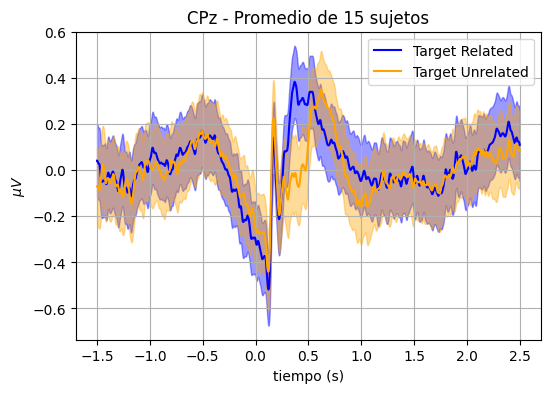

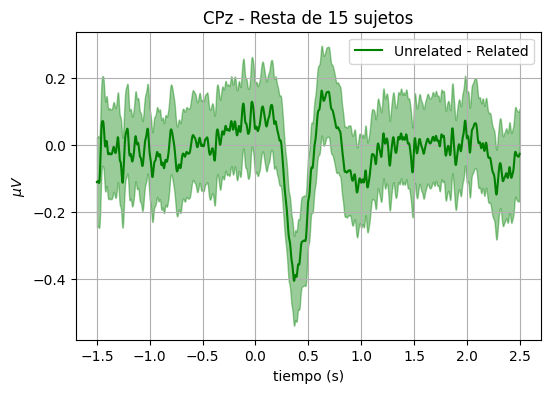

In [ ]:
y1_prom = np.mean(y1_list, axis=0)
y2_prom = np.mean(y2_list, axis=0)
y3_prom = np.mean(y3_list, axis=0)

y1std = np.array(np.std(y1_list, axis=0))
y2std = np.array(np.std(y2_list, axis=0))
y3std = np.array(np.std(y3_list, axis=0))

y1err_prom = np.sqrt(np.sum(np.square(y1std)))/np.sqrt(len(y1std))
y2err_prom = np.sqrt(np.sum(np.square(y2std)))/np.sqrt(len(y2std))
y3err_prom = np.sqrt(np.sum(np.square(y3std)))/np.sqrt(len(y3std))

y1L = y1_prom-y1err_prom
y1H = y1_prom+y1err_prom
y2L = y2_prom-y2err_prom
y2H = y2_prom+y2err_prom
y3L = y3_prom-y3err_prom
y3H = y3_prom+y3err_prom

n = len(y1_list)
plt.figure(figsize=(6,4))
plt.title('CPz - Promedio de '+ str(n) + ' sujetos')
plt.plot(tiempo,y1_prom,c='b',label='Target Related')
plt.fill_between(tiempo,y1L,y1H,color='b',alpha=0.4 )

plt.plot(tiempo,y2_prom,c='orange',label='Target Unrelated')
plt.fill_between(tiempo,y2L,y2H,color='orange',alpha=0.4 )
plt.xlabel('tiempo (s)')
plt.ylabel(r'$\mu V$')
plt.grid(True)
plt.legend()

plt.figure(figsize=(6,4))
plt.title(f'CPz - Resta de '+ str(n) + ' sujetos')
plt.plot(tiempo,y3_prom,c='g',label='Unrelated - Related')
plt.fill_between(tiempo,y3L,y3H,color='g',alpha=0.4 )
plt.grid(True)
plt.xlabel('tiempo (s)')
plt.ylabel(r'$\mu V$')
plt.legend()

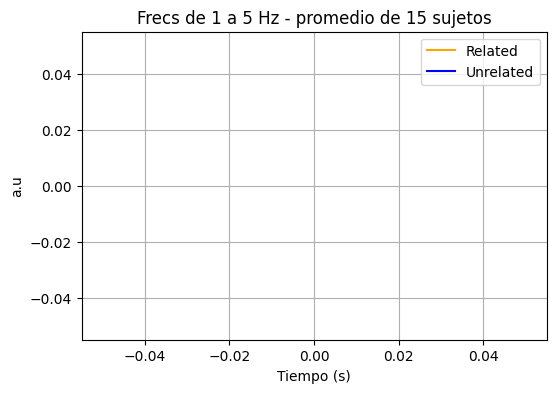

In [ ]:
#analisis de frecuencia
theta_rel_prom = np.mean(theta_rel, axis=0)
theta_unrel_prom = np.mean(theta_unrel, axis=0)

fig=plt.figure(figsize=(6,4))
plt.grid(True)
plt.title(f'Frecs de 1 a 4 Hz - promedio de '+ str(n) + ' sujetos')
plt.plot(tiempo_freq,theta_rel_prom,c='orange',label='Related')
plt.plot(tiempo_freq,theta_unrel_prom,c='b',label='Unrelated')
plt.xlabel('Tiempo (s)')
plt.ylabel('a.u')
plt.legend() #el problema es el sujeto 4

#con n=1 y epocas de 1s

Reading /content/data/erpcore/N400/sub-002/eeg/sub-002_task-N400_eeg.fdt
Reading 0 ... 510975  =      0.000 ...   498.999 secs...
EEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=1, n_times=510976
    Range : 0 ... 510975 =      0.000 ...   498.999 secs
Ready.
Added the following bipolar channels:
VEOG
EEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=1, n_times=510976
    Range : 0 ... 510975 =      0.000 ...   498.999 secs
Ready.
Added the following bipolar channels:
HEOG
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband ed

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.3s


Fitting ICA to data using 30 channels (please be patient, this may take a while)
Selecting by number: 15 components
Fitting ICA took 22.6s.
Applying ICA to Raw instance
    Transforming to ICA space (15 components)
    Zeroing out 2 ICA components
    Projecting back using 30 PCA components
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['111', '112', '121', '122', '201', '202', '211', '212', '221', '222']
Not setting metadata
120 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 60 events and 1639 original time points ...
0 bad epochs dropped
Using data from preloaded Raw for 60 events and 1639 original time points ...
0 bad epochs dropped
Using data from preloaded Raw for 120 events and 1639 original time points ...
    Rejecting  epoch based on EEG : ['PO7']
1 bad epochs dropped
Using data from preloaded Raw for 5

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    1.9s


Using data from preloaded Raw for 60 events and 1639 original time points ...


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    3.2s


Applying baseline correction (mode: logratio)


<ipython-input-4-dcae21b24c53>:69: FutureWarning: Parameters `vmin` and `vmax` are deprecated, use `vlim` instead.
  power_trel.plot(14, baseline=(-0.3, 0), mode="logratio", vmin=-0.8, vmax=0.8, title=f'target related CPz - sujeto {i+1}')


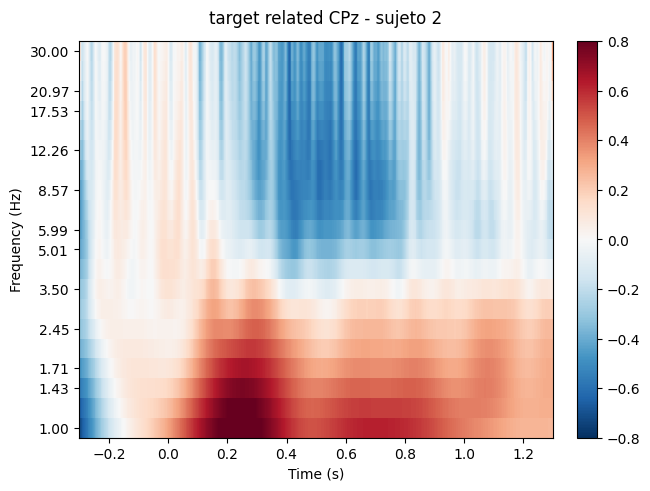

Applying baseline correction (mode: logratio)


<ipython-input-4-dcae21b24c53>:70: FutureWarning: Parameters `vmin` and `vmax` are deprecated, use `vlim` instead.
  power_turel.plot(14, baseline=(-0.3, 0), mode="logratio",  vmin=-0.8, vmax=0.8, title=f'target unrelated CPz - sujeto {i+1}')


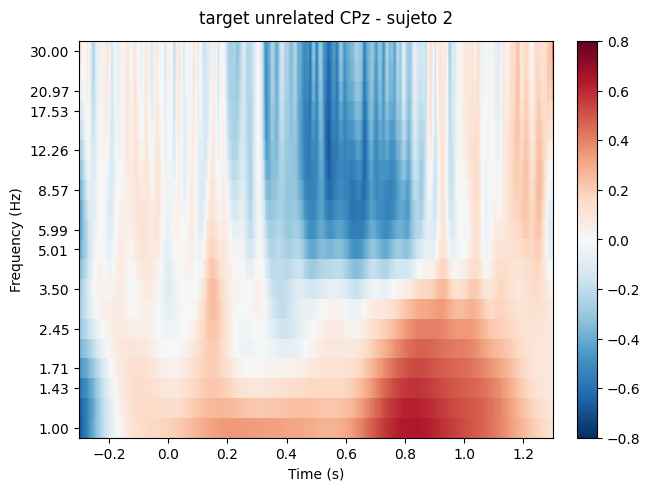

Reading /content/data/erpcore/N400/sub-003/eeg/sub-003_task-N400_eeg.fdt
Reading 0 ... 428031  =      0.000 ...   417.999 secs...
EEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=1, n_times=428032
    Range : 0 ... 428031 =      0.000 ...   417.999 secs
Ready.
Added the following bipolar channels:
VEOG
EEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=1, n_times=428032
    Range : 0 ... 428031 =      0.000 ...   417.999 secs
Ready.
Added the following bipolar channels:
HEOG
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband ed

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.3s


Fitting ICA to data using 30 channels (please be patient, this may take a while)
Selecting by number: 15 components
Fitting ICA took 23.3s.
Applying ICA to Raw instance
    Transforming to ICA space (15 components)
    Zeroing out 2 ICA components
    Projecting back using 30 PCA components
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['111', '112', '121', '122', '201', '202', '211', '212', '221', '222']
Not setting metadata
120 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 60 events and 1639 original time points ...
0 bad epochs dropped
Using data from preloaded Raw for 60 events and 1639 original time points ...
0 bad epochs dropped
Using data from preloaded Raw for 120 events and 1639 original time points ...
    Rejecting  epoch based on EEG : ['FP1']
    Rejecting  epoch based on EEG : ['FP1', 'F8']
    Re

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    2.7s


Using data from preloaded Raw for 57 events and 1639 original time points ...


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    1.8s


Applying baseline correction (mode: logratio)


<ipython-input-4-dcae21b24c53>:69: FutureWarning: Parameters `vmin` and `vmax` are deprecated, use `vlim` instead.
  power_trel.plot(14, baseline=(-0.3, 0), mode="logratio", vmin=-0.8, vmax=0.8, title=f'target related CPz - sujeto {i+1}')


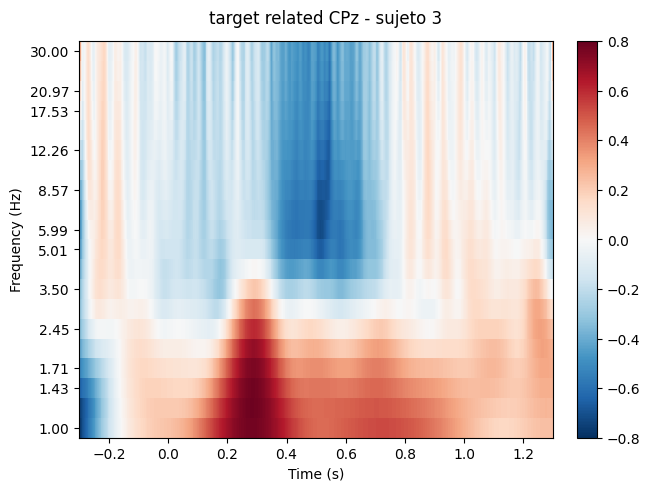

Applying baseline correction (mode: logratio)


<ipython-input-4-dcae21b24c53>:70: FutureWarning: Parameters `vmin` and `vmax` are deprecated, use `vlim` instead.
  power_turel.plot(14, baseline=(-0.3, 0), mode="logratio",  vmin=-0.8, vmax=0.8, title=f'target unrelated CPz - sujeto {i+1}')


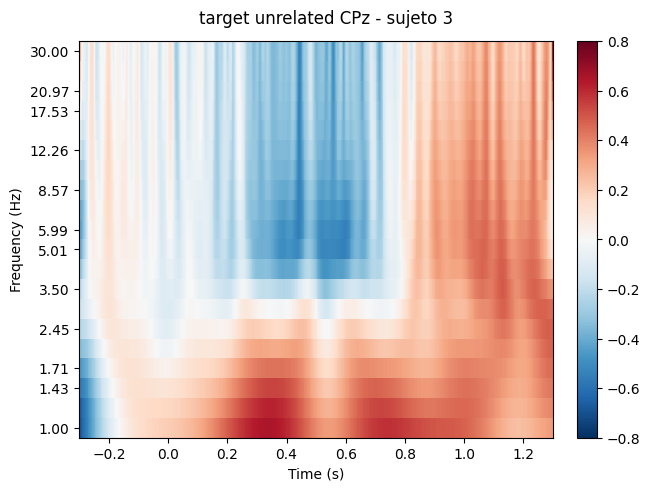

Reading /content/data/erpcore/N400/sub-004/eeg/sub-004_task-N400_eeg.fdt
Reading 0 ... 634879  =      0.000 ...   619.999 secs...
EEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=1, n_times=634880
    Range : 0 ... 634879 =      0.000 ...   619.999 secs
Ready.
Added the following bipolar channels:
VEOG
EEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=1, n_times=634880
    Range : 0 ... 634879 =      0.000 ...   619.999 secs
Ready.
Added the following bipolar channels:
HEOG
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband ed

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.4s


Fitting ICA to data using 30 channels (please be patient, this may take a while)
Selecting by number: 15 components


<ipython-input-4-dcae21b24c53>:38: RuntimeWarning: Using n_components=15 (resulting in n_components_=15) may lead to an unstable mixing matrix estimation because the ratio between the largest (30) and smallest (3.7e-07) variances is too large (> 1e6); consider setting n_components=0.999999 or an integer <= 4
  ica = ica.fit(raw)


Fitting ICA took 33.2s.
Applying ICA to Raw instance
    Transforming to ICA space (15 components)
    Zeroing out 0 ICA components
    Projecting back using 30 PCA components
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['111', '112', '121', '122', '201', '202', '211', '212', '221', '222']
Not setting metadata
120 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 60 events and 1639 original time points ...
0 bad epochs dropped
Using data from preloaded Raw for 60 events and 1639 original time points ...
0 bad epochs dropped
Using data from preloaded Raw for 120 events and 1639 original time points ...
    Rejecting  epoch based on EEG : ['FP1', 'FP2']
    Rejecting  epoch based on EEG : ['FP1', 'FP2']
    Rejecting  epoch based on EEG : ['FP1', 'FP2']
    Rejecting  epoch based on EEG : ['FP1', 'FP2']
    Rejectin

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.3s


Using data from preloaded Raw for 6 events and 1639 original time points ...


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.3s


Applying baseline correction (mode: logratio)


<ipython-input-4-dcae21b24c53>:69: FutureWarning: Parameters `vmin` and `vmax` are deprecated, use `vlim` instead.
  power_trel.plot(14, baseline=(-0.3, 0), mode="logratio", vmin=-0.8, vmax=0.8, title=f'target related CPz - sujeto {i+1}')


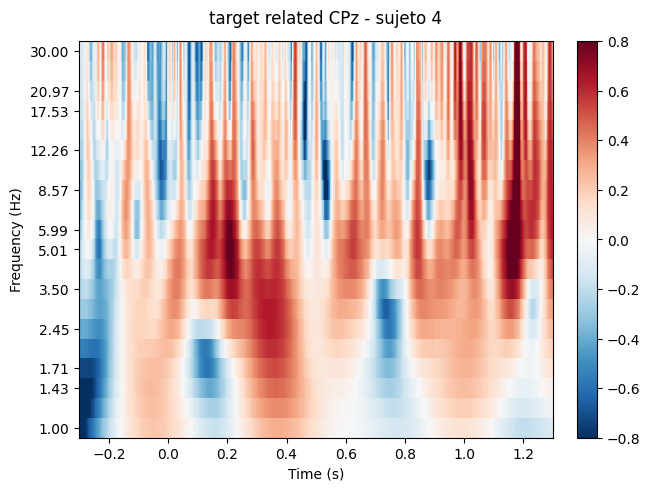

Applying baseline correction (mode: logratio)


<ipython-input-4-dcae21b24c53>:70: FutureWarning: Parameters `vmin` and `vmax` are deprecated, use `vlim` instead.
  power_turel.plot(14, baseline=(-0.3, 0), mode="logratio",  vmin=-0.8, vmax=0.8, title=f'target unrelated CPz - sujeto {i+1}')


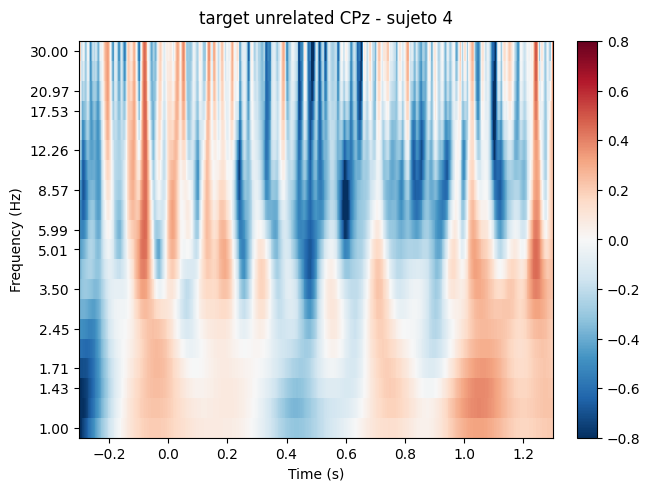

Reading /content/data/erpcore/N400/sub-005/eeg/sub-005_task-N400_eeg.fdt
Reading 0 ... 437247  =      0.000 ...   426.999 secs...
EEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=1, n_times=437248
    Range : 0 ... 437247 =      0.000 ...   426.999 secs
Ready.
Added the following bipolar channels:
VEOG
EEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=1, n_times=437248
    Range : 0 ... 437247 =      0.000 ...   426.999 secs
Ready.
Added the following bipolar channels:
HEOG
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband ed

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.5s


Fitting ICA to data using 30 channels (please be patient, this may take a while)
Selecting by number: 15 components
Fitting ICA took 19.7s.
Applying ICA to Raw instance
    Transforming to ICA space (15 components)
    Zeroing out 2 ICA components
    Projecting back using 30 PCA components
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['111', '112', '121', '122', '201', '202', '211', '212', '221', '222']
Not setting metadata
120 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 60 events and 1639 original time points ...
0 bad epochs dropped
Using data from preloaded Raw for 60 events and 1639 original time points ...
0 bad epochs dropped
Using data from preloaded Raw for 120 events and 1639 original time points ...
    Rejecting  epoch based on EEG : ['FP2']
    Rejecting  epoch based on EEG : ['FP2']
    Rejectin

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    2.4s


Using data from preloaded Raw for 59 events and 1639 original time points ...


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    1.8s


Applying baseline correction (mode: logratio)


<ipython-input-4-dcae21b24c53>:69: FutureWarning: Parameters `vmin` and `vmax` are deprecated, use `vlim` instead.
  power_trel.plot(14, baseline=(-0.3, 0), mode="logratio", vmin=-0.8, vmax=0.8, title=f'target related CPz - sujeto {i+1}')


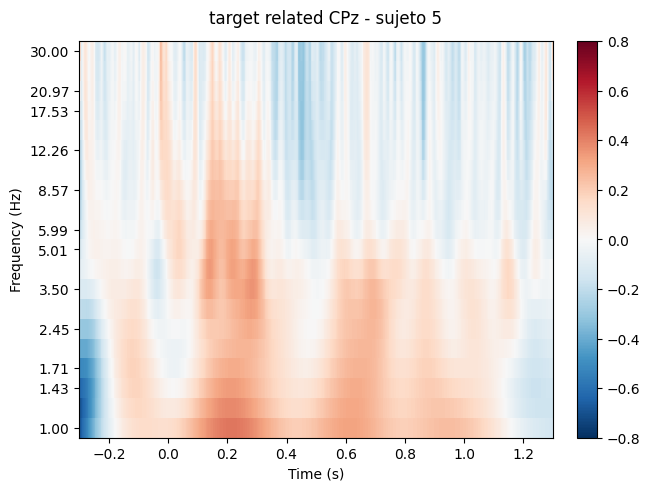

Applying baseline correction (mode: logratio)


<ipython-input-4-dcae21b24c53>:70: FutureWarning: Parameters `vmin` and `vmax` are deprecated, use `vlim` instead.
  power_turel.plot(14, baseline=(-0.3, 0), mode="logratio",  vmin=-0.8, vmax=0.8, title=f'target unrelated CPz - sujeto {i+1}')


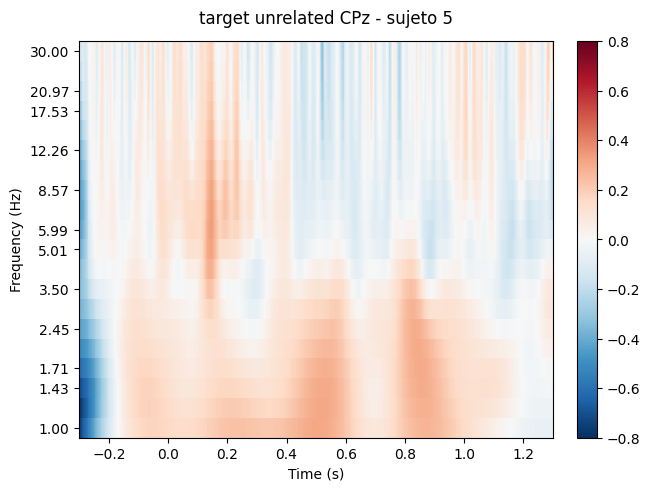

Reading /content/data/erpcore/N400/sub-006/eeg/sub-006_task-N400_eeg.fdt
Reading 0 ... 406527  =      0.000 ...   396.999 secs...
EEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=1, n_times=406528
    Range : 0 ... 406527 =      0.000 ...   396.999 secs
Ready.
Added the following bipolar channels:
VEOG
EEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=1, n_times=406528
    Range : 0 ... 406527 =      0.000 ...   396.999 secs
Ready.
Added the following bipolar channels:
HEOG
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband ed

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.3s


Fitting ICA to data using 30 channels (please be patient, this may take a while)
Selecting by number: 15 components
Fitting ICA took 31.4s.
Applying ICA to Raw instance
    Transforming to ICA space (15 components)
    Zeroing out 2 ICA components
    Projecting back using 30 PCA components
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['111', '112', '121', '122', '201', '202', '211', '212', '221', '222']
Not setting metadata
120 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 60 events and 1639 original time points ...
0 bad epochs dropped
Using data from preloaded Raw for 60 events and 1639 original time points ...
0 bad epochs dropped
Using data from preloaded Raw for 120 events and 1639 original time points ...
    Rejecting  epoch based on EEG : ['FC4']
    Rejecting  epoch based on EEG : ['FC4']
    Rejectin

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.9s


Using data from preloaded Raw for 19 events and 1639 original time points ...


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.6s


Applying baseline correction (mode: logratio)


<ipython-input-4-dcae21b24c53>:69: FutureWarning: Parameters `vmin` and `vmax` are deprecated, use `vlim` instead.
  power_trel.plot(14, baseline=(-0.3, 0), mode="logratio", vmin=-0.8, vmax=0.8, title=f'target related CPz - sujeto {i+1}')


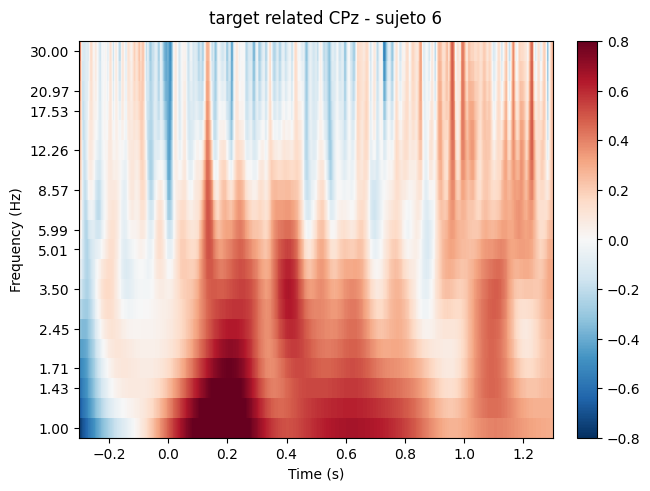

Applying baseline correction (mode: logratio)


<ipython-input-4-dcae21b24c53>:70: FutureWarning: Parameters `vmin` and `vmax` are deprecated, use `vlim` instead.
  power_turel.plot(14, baseline=(-0.3, 0), mode="logratio",  vmin=-0.8, vmax=0.8, title=f'target unrelated CPz - sujeto {i+1}')


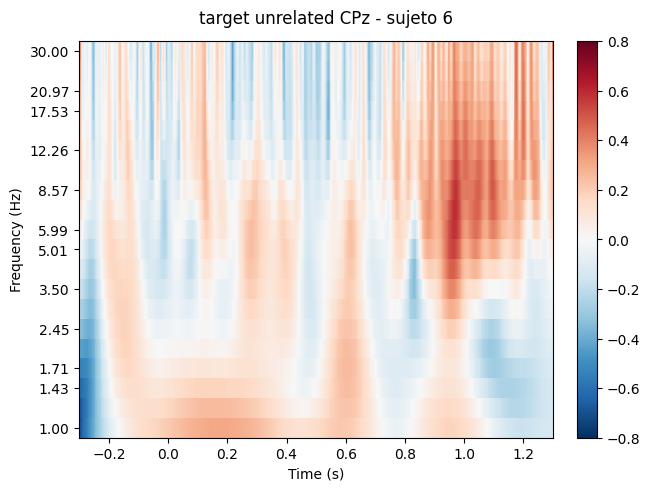

Reading /content/data/erpcore/N400/sub-007/eeg/sub-007_task-N400_eeg.fdt
Reading 0 ... 410623  =      0.000 ...   400.999 secs...
EEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=1, n_times=410624
    Range : 0 ... 410623 =      0.000 ...   400.999 secs
Ready.
Added the following bipolar channels:
VEOG
EEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=1, n_times=410624
    Range : 0 ... 410623 =      0.000 ...   400.999 secs
Ready.
Added the following bipolar channels:
HEOG
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband ed

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.4s


Fitting ICA to data using 30 channels (please be patient, this may take a while)
Selecting by number: 15 components
Fitting ICA took 16.8s.
Applying ICA to Raw instance
    Transforming to ICA space (15 components)
    Zeroing out 2 ICA components
    Projecting back using 30 PCA components
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['111', '112', '121', '122', '201', '202', '211', '212', '221', '222']
Not setting metadata
120 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 60 events and 1639 original time points ...
0 bad epochs dropped
Using data from preloaded Raw for 60 events and 1639 original time points ...
0 bad epochs dropped
Using data from preloaded Raw for 120 events and 1639 original time points ...
0 bad epochs dropped
Using data from preloaded Raw for 60 events and 1639 original time points ...


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    1.9s


Using data from preloaded Raw for 60 events and 1639 original time points ...


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    3.1s


Applying baseline correction (mode: logratio)


<ipython-input-4-dcae21b24c53>:69: FutureWarning: Parameters `vmin` and `vmax` are deprecated, use `vlim` instead.
  power_trel.plot(14, baseline=(-0.3, 0), mode="logratio", vmin=-0.8, vmax=0.8, title=f'target related CPz - sujeto {i+1}')


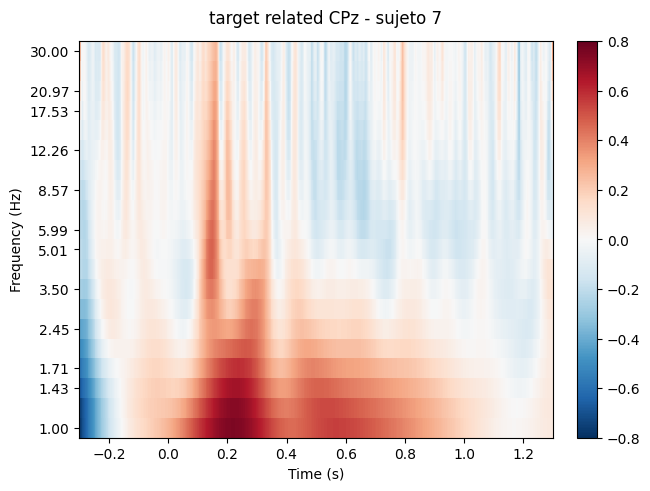

Applying baseline correction (mode: logratio)


<ipython-input-4-dcae21b24c53>:70: FutureWarning: Parameters `vmin` and `vmax` are deprecated, use `vlim` instead.
  power_turel.plot(14, baseline=(-0.3, 0), mode="logratio",  vmin=-0.8, vmax=0.8, title=f'target unrelated CPz - sujeto {i+1}')


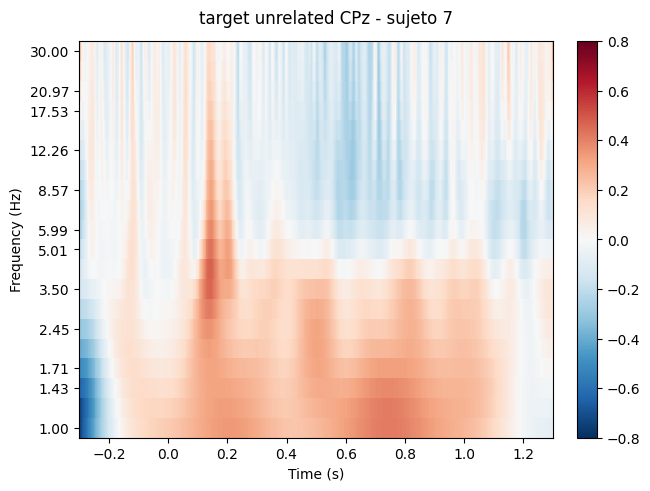

Reading /content/data/erpcore/N400/sub-008/eeg/sub-008_task-N400_eeg.fdt
Reading 0 ... 487423  =      0.000 ...   475.999 secs...
EEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=1, n_times=487424
    Range : 0 ... 487423 =      0.000 ...   475.999 secs
Ready.
Added the following bipolar channels:
VEOG
EEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=1, n_times=487424
    Range : 0 ... 487423 =      0.000 ...   475.999 secs
Ready.
Added the following bipolar channels:
HEOG
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband ed

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.3s


Fitting ICA to data using 30 channels (please be patient, this may take a while)
Selecting by number: 15 components
Fitting ICA took 18.1s.
Applying ICA to Raw instance
    Transforming to ICA space (15 components)
    Zeroing out 2 ICA components
    Projecting back using 30 PCA components
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['111', '112', '121', '122', '201', '202', '211', '212', '221', '222']
Not setting metadata
120 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 60 events and 1639 original time points ...
0 bad epochs dropped
Using data from preloaded Raw for 60 events and 1639 original time points ...
0 bad epochs dropped
Using data from preloaded Raw for 120 events and 1639 original time points ...
0 bad epochs dropped
Using data from preloaded Raw for 60 events and 1639 original time points ...


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    1.9s


Using data from preloaded Raw for 60 events and 1639 original time points ...


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    1.8s


Applying baseline correction (mode: logratio)


<ipython-input-4-dcae21b24c53>:69: FutureWarning: Parameters `vmin` and `vmax` are deprecated, use `vlim` instead.
  power_trel.plot(14, baseline=(-0.3, 0), mode="logratio", vmin=-0.8, vmax=0.8, title=f'target related CPz - sujeto {i+1}')


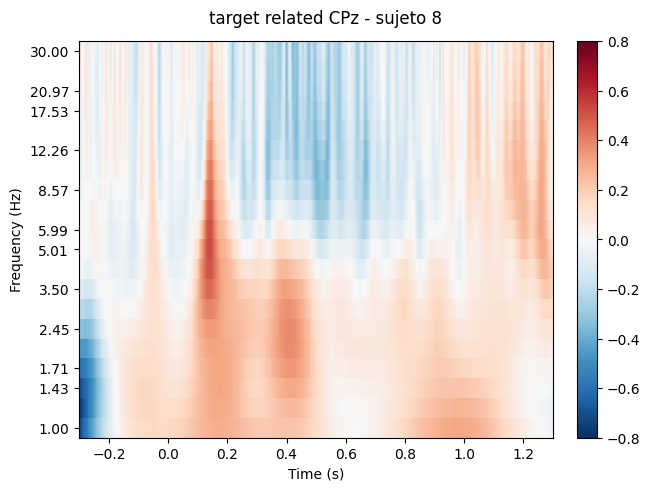

Applying baseline correction (mode: logratio)


<ipython-input-4-dcae21b24c53>:70: FutureWarning: Parameters `vmin` and `vmax` are deprecated, use `vlim` instead.
  power_turel.plot(14, baseline=(-0.3, 0), mode="logratio",  vmin=-0.8, vmax=0.8, title=f'target unrelated CPz - sujeto {i+1}')


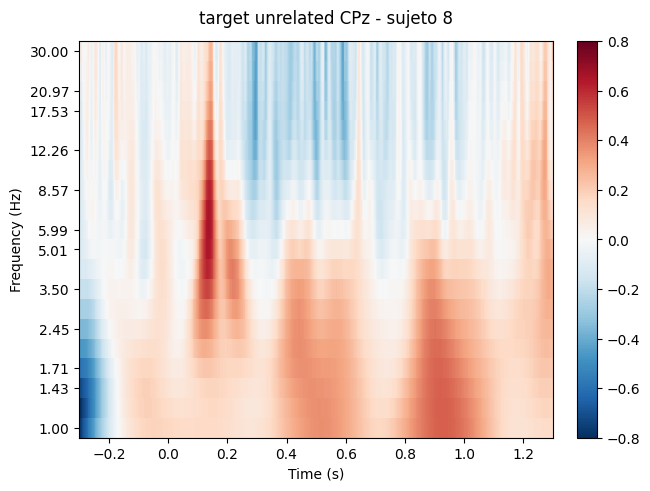

Reading /content/data/erpcore/N400/sub-009/eeg/sub-009_task-N400_eeg.fdt
Reading 0 ... 396287  =      0.000 ...   386.999 secs...
EEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=1, n_times=396288
    Range : 0 ... 396287 =      0.000 ...   386.999 secs
Ready.
Added the following bipolar channels:
VEOG
EEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=1, n_times=396288
    Range : 0 ... 396287 =      0.000 ...   386.999 secs
Ready.
Added the following bipolar channels:
HEOG
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband ed

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.4s


Fitting ICA to data using 30 channels (please be patient, this may take a while)
Selecting by number: 15 components
Fitting ICA took 11.8s.
Applying ICA to Raw instance
    Transforming to ICA space (15 components)
    Zeroing out 2 ICA components
    Projecting back using 30 PCA components
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['111', '112', '121', '122', '201', '202', '211', '212', '221', '222']
Not setting metadata
120 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 60 events and 1639 original time points ...
0 bad epochs dropped
Using data from preloaded Raw for 60 events and 1639 original time points ...
0 bad epochs dropped
Using data from preloaded Raw for 120 events and 1639 original time points ...
    Rejecting  epoch based on EEG : ['P10']
    Rejecting  epoch based on EEG : ['F8']
    Rejecting

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    2.3s


Using data from preloaded Raw for 59 events and 1639 original time points ...


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    1.8s


Applying baseline correction (mode: logratio)


<ipython-input-4-dcae21b24c53>:69: FutureWarning: Parameters `vmin` and `vmax` are deprecated, use `vlim` instead.
  power_trel.plot(14, baseline=(-0.3, 0), mode="logratio", vmin=-0.8, vmax=0.8, title=f'target related CPz - sujeto {i+1}')


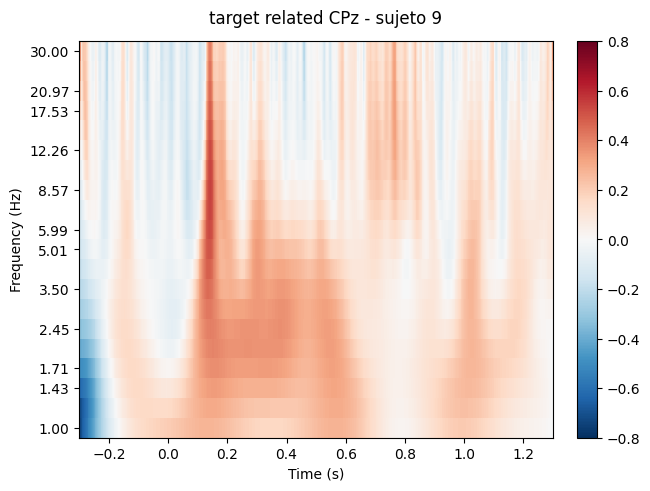

Applying baseline correction (mode: logratio)


<ipython-input-4-dcae21b24c53>:70: FutureWarning: Parameters `vmin` and `vmax` are deprecated, use `vlim` instead.
  power_turel.plot(14, baseline=(-0.3, 0), mode="logratio",  vmin=-0.8, vmax=0.8, title=f'target unrelated CPz - sujeto {i+1}')


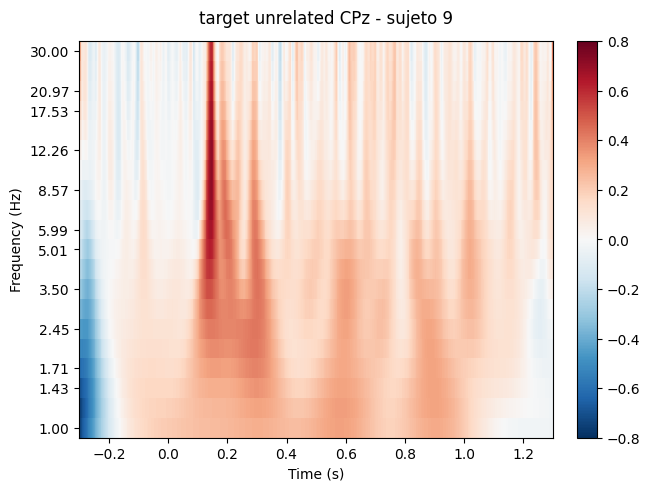

Reading /content/data/erpcore/N400/sub-010/eeg/sub-010_task-N400_eeg.fdt
Reading 0 ... 472063  =      0.000 ...   460.999 secs...
EEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=1, n_times=472064
    Range : 0 ... 472063 =      0.000 ...   460.999 secs
Ready.
Added the following bipolar channels:
VEOG
EEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=1, n_times=472064
    Range : 0 ... 472063 =      0.000 ...   460.999 secs
Ready.
Added the following bipolar channels:
HEOG
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband ed

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.4s


Fitting ICA to data using 30 channels (please be patient, this may take a while)
Selecting by number: 15 components
Fitting ICA took 15.8s.
Applying ICA to Raw instance
    Transforming to ICA space (15 components)
    Zeroing out 2 ICA components
    Projecting back using 30 PCA components
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['111', '112', '121', '122', '201', '202', '211', '212', '221', '222']
Not setting metadata
120 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 60 events and 1639 original time points ...
0 bad epochs dropped
Using data from preloaded Raw for 60 events and 1639 original time points ...
0 bad epochs dropped
Using data from preloaded Raw for 120 events and 1639 original time points ...
    Rejecting  epoch based on EEG : ['Fz']
    Rejecting  epoch based on EEG : ['C5']
    Rejecting 

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    6.7s


Using data from preloaded Raw for 58 events and 1639 original time points ...


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    6.3s


Applying baseline correction (mode: logratio)


<ipython-input-4-dcae21b24c53>:69: FutureWarning: Parameters `vmin` and `vmax` are deprecated, use `vlim` instead.
  power_trel.plot(14, baseline=(-0.3, 0), mode="logratio", vmin=-0.8, vmax=0.8, title=f'target related CPz - sujeto {i+1}')


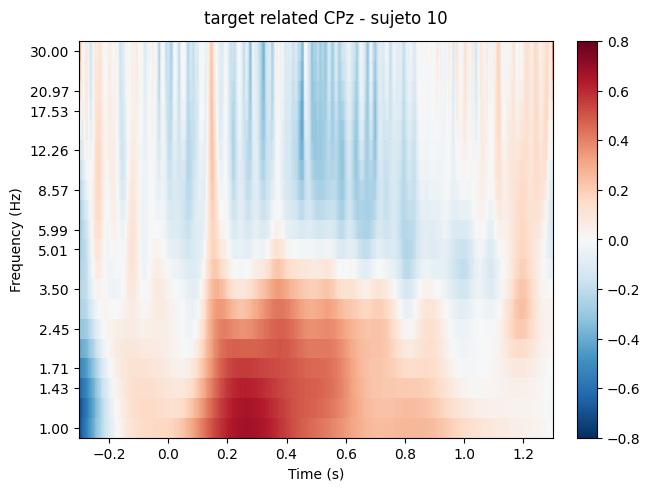

Applying baseline correction (mode: logratio)


<ipython-input-4-dcae21b24c53>:70: FutureWarning: Parameters `vmin` and `vmax` are deprecated, use `vlim` instead.
  power_turel.plot(14, baseline=(-0.3, 0), mode="logratio",  vmin=-0.8, vmax=0.8, title=f'target unrelated CPz - sujeto {i+1}')


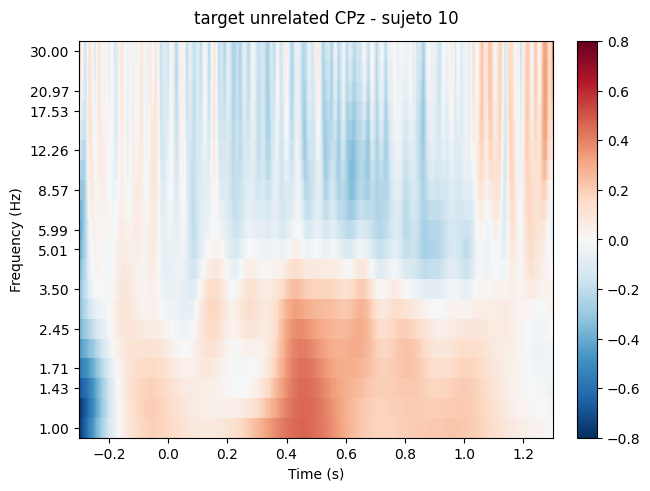

Reading /content/data/erpcore/N400/sub-011/eeg/sub-011_task-N400_eeg.fdt
Reading 0 ... 414719  =      0.000 ...   404.999 secs...
EEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=1, n_times=414720
    Range : 0 ... 414719 =      0.000 ...   404.999 secs
Ready.
Added the following bipolar channels:
VEOG
EEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=1, n_times=414720
    Range : 0 ... 414719 =      0.000 ...   404.999 secs
Ready.
Added the following bipolar channels:
HEOG
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband ed

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.4s


Fitting ICA to data using 30 channels (please be patient, this may take a while)
Selecting by number: 15 components
Fitting ICA took 12.9s.
Applying ICA to Raw instance
    Transforming to ICA space (15 components)
    Zeroing out 2 ICA components
    Projecting back using 30 PCA components
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['111', '112', '121', '122', '201', '202', '211', '212', '221', '222']
Not setting metadata
120 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 60 events and 1639 original time points ...
0 bad epochs dropped
Using data from preloaded Raw for 60 events and 1639 original time points ...
0 bad epochs dropped
Using data from preloaded Raw for 120 events and 1639 original time points ...
    Rejecting  epoch based on EEG : ['P7']
    Rejecting  epoch based on EEG : ['P7']
    Rejecting 

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    2.5s


Using data from preloaded Raw for 50 events and 1639 original time points ...


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    1.5s


Applying baseline correction (mode: logratio)


<ipython-input-4-dcae21b24c53>:69: FutureWarning: Parameters `vmin` and `vmax` are deprecated, use `vlim` instead.
  power_trel.plot(14, baseline=(-0.3, 0), mode="logratio", vmin=-0.8, vmax=0.8, title=f'target related CPz - sujeto {i+1}')


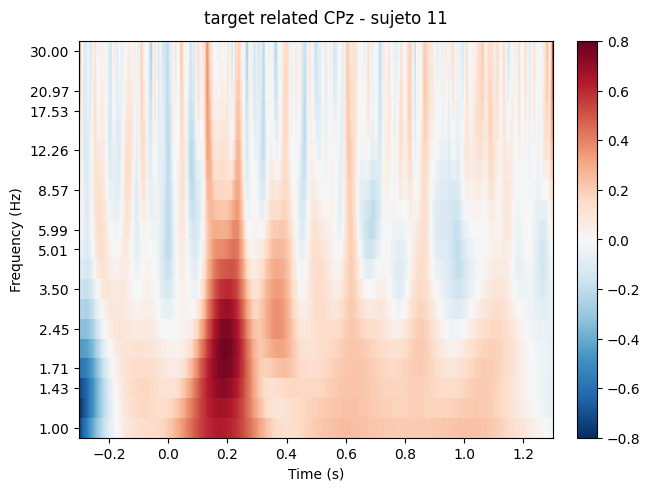

Applying baseline correction (mode: logratio)


<ipython-input-4-dcae21b24c53>:70: FutureWarning: Parameters `vmin` and `vmax` are deprecated, use `vlim` instead.
  power_turel.plot(14, baseline=(-0.3, 0), mode="logratio",  vmin=-0.8, vmax=0.8, title=f'target unrelated CPz - sujeto {i+1}')


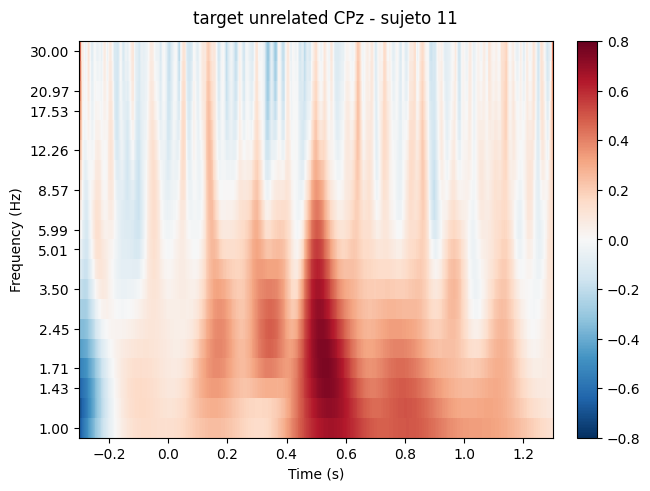

Reading /content/data/erpcore/N400/sub-012/eeg/sub-012_task-N400_eeg.fdt
Reading 0 ... 399359  =      0.000 ...   389.999 secs...
EEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=1, n_times=399360
    Range : 0 ... 399359 =      0.000 ...   389.999 secs
Ready.
Added the following bipolar channels:
VEOG
EEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=1, n_times=399360
    Range : 0 ... 399359 =      0.000 ...   389.999 secs
Ready.
Added the following bipolar channels:
HEOG
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband ed

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.4s


Fitting ICA to data using 30 channels (please be patient, this may take a while)
Selecting by number: 15 components
Fitting ICA took 11.3s.
Applying ICA to Raw instance
    Transforming to ICA space (15 components)
    Zeroing out 1 ICA component
    Projecting back using 30 PCA components
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['111', '112', '121', '122', '201', '202', '211', '212', '221', '222']
Not setting metadata
120 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 60 events and 1639 original time points ...
0 bad epochs dropped
Using data from preloaded Raw for 60 events and 1639 original time points ...
0 bad epochs dropped
Using data from preloaded Raw for 120 events and 1639 original time points ...
    Rejecting  epoch based on EEG : ['PO4']
    Rejecting  epoch based on EEG : ['PO4']
2 bad epochs 

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    2.1s


Using data from preloaded Raw for 59 events and 1639 original time points ...


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    1.9s


Applying baseline correction (mode: logratio)


<ipython-input-4-dcae21b24c53>:69: FutureWarning: Parameters `vmin` and `vmax` are deprecated, use `vlim` instead.
  power_trel.plot(14, baseline=(-0.3, 0), mode="logratio", vmin=-0.8, vmax=0.8, title=f'target related CPz - sujeto {i+1}')


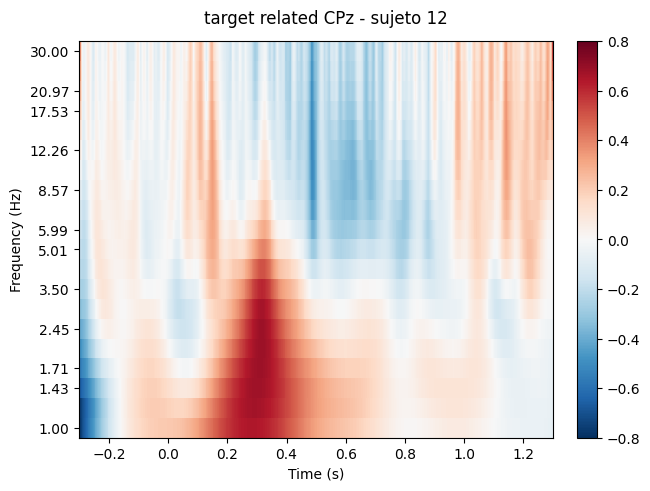

Applying baseline correction (mode: logratio)


<ipython-input-4-dcae21b24c53>:70: FutureWarning: Parameters `vmin` and `vmax` are deprecated, use `vlim` instead.
  power_turel.plot(14, baseline=(-0.3, 0), mode="logratio",  vmin=-0.8, vmax=0.8, title=f'target unrelated CPz - sujeto {i+1}')


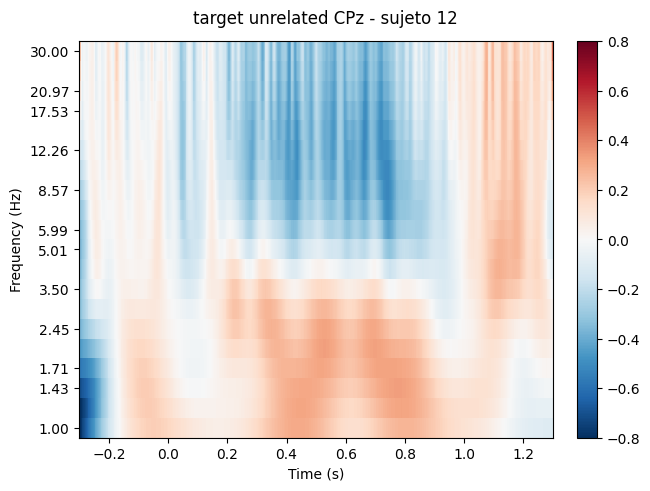

Reading /content/data/erpcore/N400/sub-013/eeg/sub-013_task-N400_eeg.fdt
Reading 0 ... 425983  =      0.000 ...   415.999 secs...
EEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=1, n_times=425984
    Range : 0 ... 425983 =      0.000 ...   415.999 secs
Ready.
Added the following bipolar channels:
VEOG
EEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=1, n_times=425984
    Range : 0 ... 425983 =      0.000 ...   415.999 secs
Ready.
Added the following bipolar channels:
HEOG
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband ed

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.4s


Fitting ICA to data using 30 channels (please be patient, this may take a while)
Selecting by number: 15 components
Fitting ICA took 18.6s.
Applying ICA to Raw instance
    Transforming to ICA space (15 components)
    Zeroing out 1 ICA component
    Projecting back using 30 PCA components
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['111', '112', '121', '122', '201', '202', '211', '212', '221', '222']
Not setting metadata
120 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 60 events and 1639 original time points ...
0 bad epochs dropped
Using data from preloaded Raw for 60 events and 1639 original time points ...
0 bad epochs dropped
Using data from preloaded Raw for 120 events and 1639 original time points ...
    Rejecting  epoch based on EEG : ['FP1', 'F3', 'F7', 'FC3', 'C3', 'C5', 'P9', 'Fz', 'FCz', 'P10']


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    1.8s


Using data from preloaded Raw for 60 events and 1639 original time points ...


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    1.8s


Applying baseline correction (mode: logratio)


<ipython-input-4-dcae21b24c53>:69: FutureWarning: Parameters `vmin` and `vmax` are deprecated, use `vlim` instead.
  power_trel.plot(14, baseline=(-0.3, 0), mode="logratio", vmin=-0.8, vmax=0.8, title=f'target related CPz - sujeto {i+1}')


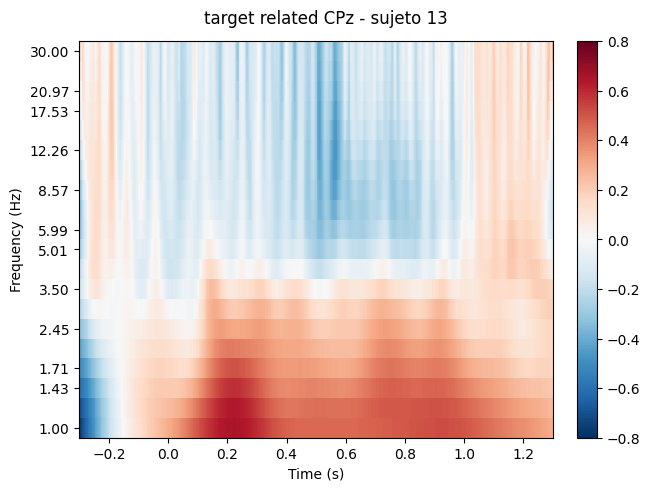

Applying baseline correction (mode: logratio)


<ipython-input-4-dcae21b24c53>:70: FutureWarning: Parameters `vmin` and `vmax` are deprecated, use `vlim` instead.
  power_turel.plot(14, baseline=(-0.3, 0), mode="logratio",  vmin=-0.8, vmax=0.8, title=f'target unrelated CPz - sujeto {i+1}')


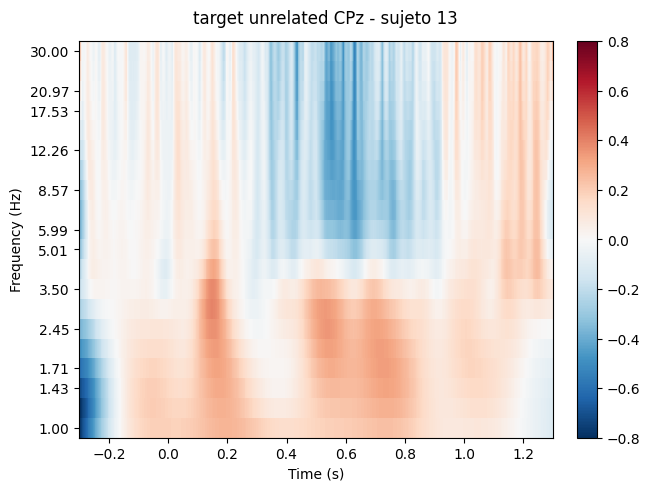

Reading /content/data/erpcore/N400/sub-014/eeg/sub-014_task-N400_eeg.fdt
Reading 0 ... 414719  =      0.000 ...   404.999 secs...
EEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=1, n_times=414720
    Range : 0 ... 414719 =      0.000 ...   404.999 secs
Ready.
Added the following bipolar channels:
VEOG
EEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=1, n_times=414720
    Range : 0 ... 414719 =      0.000 ...   404.999 secs
Ready.
Added the following bipolar channels:
HEOG
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband ed

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.4s


Fitting ICA to data using 30 channels (please be patient, this may take a while)
Selecting by number: 15 components
Fitting ICA took 21.5s.
Applying ICA to Raw instance
    Transforming to ICA space (15 components)
    Zeroing out 2 ICA components
    Projecting back using 30 PCA components
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['111', '112', '121', '122', '201', '202', '211', '212', '221', '222']
Not setting metadata
120 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 60 events and 1639 original time points ...
0 bad epochs dropped
Using data from preloaded Raw for 60 events and 1639 original time points ...
0 bad epochs dropped
Using data from preloaded Raw for 120 events and 1639 original time points ...
    Rejecting  epoch based on EEG : ['Cz']
    Rejecting  epoch based on EEG : ['PO3']
    Rejecting

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    1.9s


Using data from preloaded Raw for 59 events and 1639 original time points ...


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    2.2s


Applying baseline correction (mode: logratio)


<ipython-input-4-dcae21b24c53>:69: FutureWarning: Parameters `vmin` and `vmax` are deprecated, use `vlim` instead.
  power_trel.plot(14, baseline=(-0.3, 0), mode="logratio", vmin=-0.8, vmax=0.8, title=f'target related CPz - sujeto {i+1}')


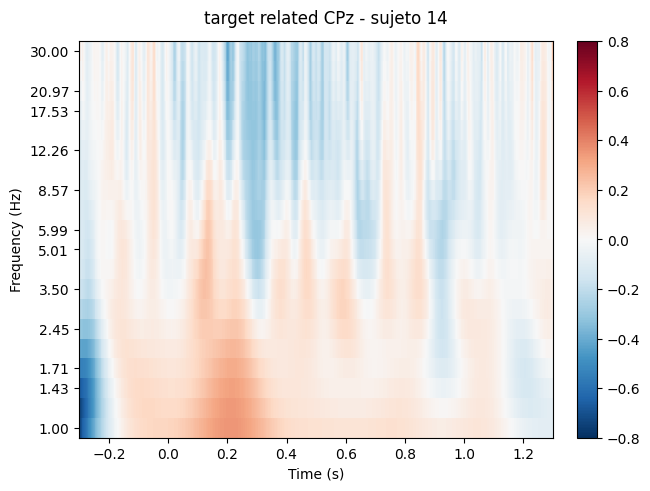

Applying baseline correction (mode: logratio)


<ipython-input-4-dcae21b24c53>:70: FutureWarning: Parameters `vmin` and `vmax` are deprecated, use `vlim` instead.
  power_turel.plot(14, baseline=(-0.3, 0), mode="logratio",  vmin=-0.8, vmax=0.8, title=f'target unrelated CPz - sujeto {i+1}')


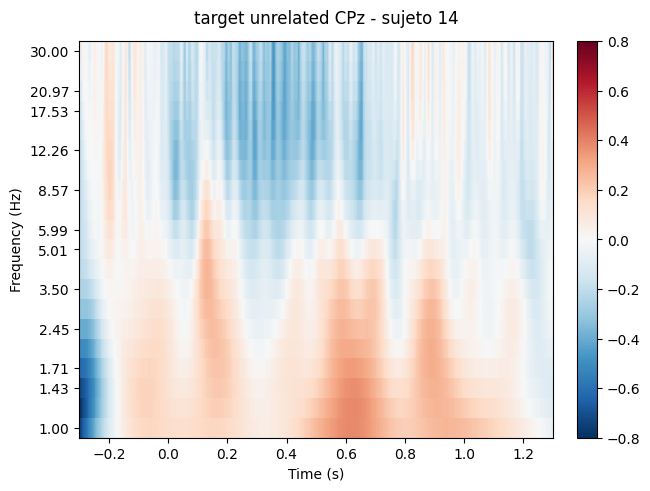

Reading /content/data/erpcore/N400/sub-015/eeg/sub-015_task-N400_eeg.fdt
Reading 0 ... 410623  =      0.000 ...   400.999 secs...
EEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=1, n_times=410624
    Range : 0 ... 410623 =      0.000 ...   400.999 secs
Ready.
Added the following bipolar channels:
VEOG
EEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=1, n_times=410624
    Range : 0 ... 410623 =      0.000 ...   400.999 secs
Ready.
Added the following bipolar channels:
HEOG
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband ed

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.4s


Fitting ICA to data using 30 channels (please be patient, this may take a while)
Selecting by number: 15 components
Fitting ICA took 16.6s.
Applying ICA to Raw instance
    Transforming to ICA space (15 components)
    Zeroing out 1 ICA component
    Projecting back using 30 PCA components
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['111', '112', '121', '122', '201', '202', '211', '212', '221', '222']
Not setting metadata
120 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 60 events and 1639 original time points ...
0 bad epochs dropped
Using data from preloaded Raw for 60 events and 1639 original time points ...
0 bad epochs dropped
Using data from preloaded Raw for 120 events and 1639 original time points ...
    Rejecting  epoch based on EEG : ['F7', 'F8']
1 bad epochs dropped
Using data from preloaded Raw f

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    2.7s


Using data from preloaded Raw for 59 events and 1639 original time points ...


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    1.8s


Applying baseline correction (mode: logratio)


<ipython-input-4-dcae21b24c53>:69: FutureWarning: Parameters `vmin` and `vmax` are deprecated, use `vlim` instead.
  power_trel.plot(14, baseline=(-0.3, 0), mode="logratio", vmin=-0.8, vmax=0.8, title=f'target related CPz - sujeto {i+1}')


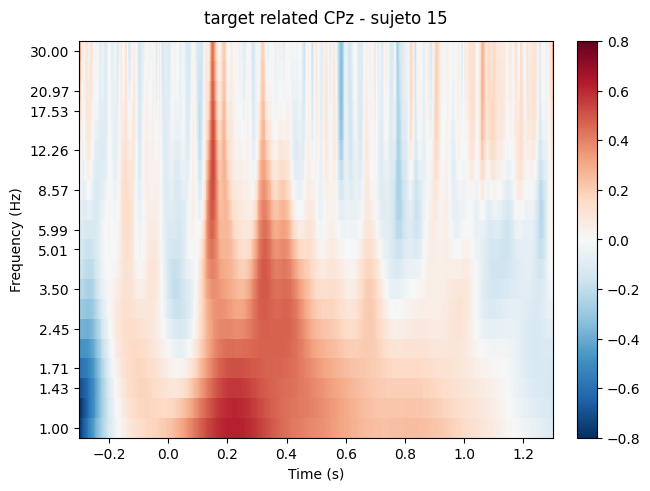

Applying baseline correction (mode: logratio)


<ipython-input-4-dcae21b24c53>:70: FutureWarning: Parameters `vmin` and `vmax` are deprecated, use `vlim` instead.
  power_turel.plot(14, baseline=(-0.3, 0), mode="logratio",  vmin=-0.8, vmax=0.8, title=f'target unrelated CPz - sujeto {i+1}')


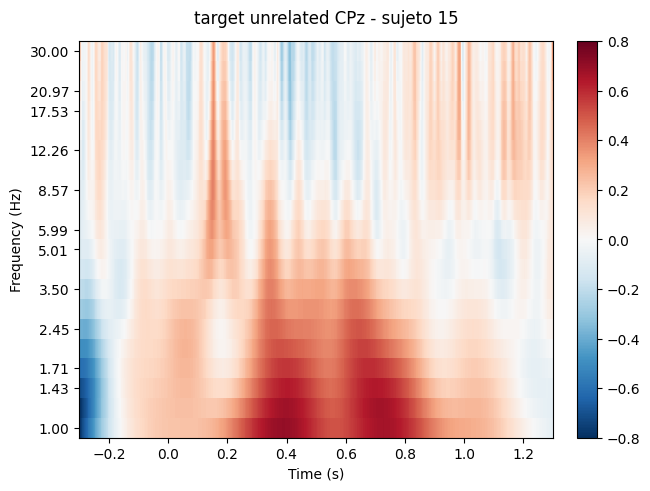

Reading /content/data/erpcore/N400/sub-016/eeg/sub-016_task-N400_eeg.fdt
Reading 0 ... 696319  =      0.000 ...   679.999 secs...
EEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=1, n_times=696320
    Range : 0 ... 696319 =      0.000 ...   679.999 secs
Ready.
Added the following bipolar channels:
VEOG
EEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=1, n_times=696320
    Range : 0 ... 696319 =      0.000 ...   679.999 secs
Ready.
Added the following bipolar channels:
HEOG
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband ed

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.5s


Fitting ICA to data using 30 channels (please be patient, this may take a while)
Selecting by number: 15 components


<ipython-input-4-dcae21b24c53>:38: RuntimeWarning: Using n_components=15 (resulting in n_components_=15) may lead to an unstable mixing matrix estimation because the ratio between the largest (30) and smallest (1.9e-06) variances is too large (> 1e6); consider setting n_components=0.999999 or an integer <= 5
  ica = ica.fit(raw)


Fitting ICA took 29.1s.
Applying ICA to Raw instance
    Transforming to ICA space (15 components)
    Zeroing out 2 ICA components
    Projecting back using 30 PCA components
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['111', '112', '121', '122', '201', '202', '211', '212', '221', '222']
Not setting metadata
120 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 60 events and 1639 original time points ...
0 bad epochs dropped
Using data from preloaded Raw for 60 events and 1639 original time points ...
0 bad epochs dropped
Using data from preloaded Raw for 120 events and 1639 original time points ...
    Rejecting  epoch based on EEG : ['P9']
    Rejecting  epoch based on EEG : ['P9']
    Rejecting  epoch based on EEG : ['P9']
    Rejecting  epoch based on EEG : ['P9']
    Rejecting  epoch based on EEG : ['PO8']


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    1.6s


Using data from preloaded Raw for 26 events and 1639 original time points ...


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    1.6s


Applying baseline correction (mode: logratio)


<ipython-input-4-dcae21b24c53>:69: FutureWarning: Parameters `vmin` and `vmax` are deprecated, use `vlim` instead.
  power_trel.plot(14, baseline=(-0.3, 0), mode="logratio", vmin=-0.8, vmax=0.8, title=f'target related CPz - sujeto {i+1}')


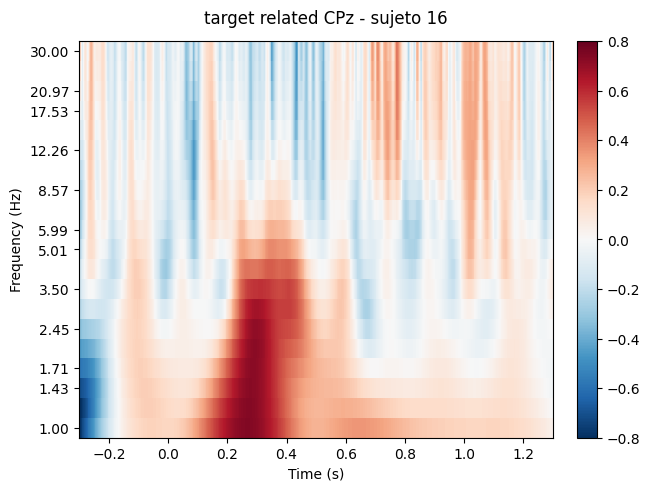

Applying baseline correction (mode: logratio)


<ipython-input-4-dcae21b24c53>:70: FutureWarning: Parameters `vmin` and `vmax` are deprecated, use `vlim` instead.
  power_turel.plot(14, baseline=(-0.3, 0), mode="logratio",  vmin=-0.8, vmax=0.8, title=f'target unrelated CPz - sujeto {i+1}')


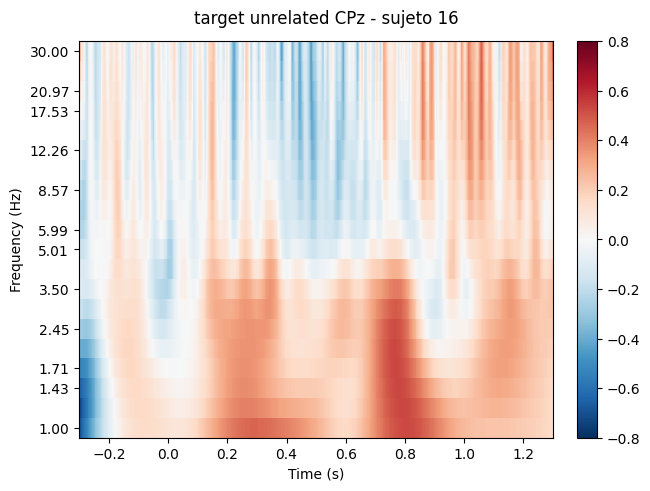

"\n    fig=plt.figure(figsize=(6,4))\n    plt.plot(tiempo_freq,Pz_power_trel,c='orange',label='Related')\n    plt.plot(tiempo_freq,Pz_power_turel,c='b',label='Unrelated')\n    plt.grid(True)\n    plt.xlabel('Tiempo (s)')\n    plt.ylabel('a.u')\n    plt.title(f'Frecs de 1 a 4 Hz - sujeto {i+1}' )\n    plt.legend()\n#"

In [4]:
#genero las listas donde guardo las variables y1, y1err, y2, y2err, y3, y3err de todos los sujetos
#para luego hacer el promedio y prop el error
#estas variables corresponden a las target words. 1-related. 2-unrelated. 3-resta.
y1_list=[]
y1err_list=[]
y2_list=[]
y2err_list=[]
y3_list=[]
y3err_list=[]
y4_list=[] #para la normalizacion

theta_rel = []
theta_unrel = []

freqs = np.logspace(*np.log10([1, 30]), num=20)

sujetos = [f'sub-{i:03d}' for i in range(1, 41)]

for i in range(1,16): #excluyo el 1 (empieza en 0)
    #importe de datos
    files_dict = get_erpcore('N400', participants=sujetos[i], path='data')

    raw_file = files_dict['raw_files'][0]
    raw = read_raw(raw_file, preload=True)
    raw.get_data()

    raw = set_bipolar_reference(raw, anode='FP1', cathode='VEOG_lower', ch_name='VEOG', drop_refs=False)
    raw = set_bipolar_reference(raw, anode='HEOG_right', cathode='HEOG_left', ch_name='HEOG', drop_refs=False)
    raw = raw.set_channel_types({'VEOG': 'eog', 'HEOG': 'eog'})
    raw = raw.drop_channels(['VEOG_lower', 'HEOG_right', 'HEOG_left'])

    raw = raw.set_montage('biosemi64', match_case=False)

    #pre-procesado
    raw = raw.filter(l_freq=1, h_freq=40) ###

    ica = ICA(n_components=15)
    ica = ica.fit(raw)
    eog_indices, eog_scores = ica.find_bads_eog(raw, ch_name=['HEOG', 'VEOG'], verbose=False)
    ica.exclude = eog_indices
    raw = ica.apply(raw)

    raw = raw.set_eeg_reference('average')

    #eventos y épocas
    events, event_id = events_from_annotations(raw)
    events = merge_events(events, ids=[1, 2],new_id=1)
    events = merge_events(events, ids=[3, 4],new_id=2)
    events = merge_events(events, ids=[7, 8],new_id=3)
    events = merge_events(events, ids=[9, 10],new_id=4)
    event_id = {'target rel': 3,'target unrel': 4}

    #epochs = Epochs(raw, events, event_id, tmin=-0.1, tmax=1, baseline=(-0.1,0)) #abierto a cambios
    #epochs = Epochs(raw, events, event_id, tmin=-1.5, tmax=2.5, baseline=(-1.5,0))
    epochs = Epochs(raw, events, event_id, tmin=-0.3, tmax=1.3, baseline=(-0.3,0))

    tiempo = epochs.times
    trel = epochs['target rel'].get_data()/1e-6
    tunrel = epochs['target unrel'].get_data()/1e-6

    #tomamos CPz
    epochs = epochs.drop_bad({'eeg': 100e-6})
    #_ = epochs.plot_image(picks='CPz', title=f'CPz - sujeto {i+1}')#####

    ch_interest= 14 #CPz
        #analisis de frecuencia (ABIERTO A CAMBIOS el baseline y ncycles)
    power_trel, itc = epochs['target rel'].compute_tfr(method="morlet",freqs=freqs,n_cycles=1,average=True,return_itc=True,decim=3)
    power_turel, itc = epochs['target unrel'].compute_tfr(method="morlet",freqs=freqs,n_cycles=1,average=True,return_itc=True,decim=3)
    power_trel.plot(14, baseline=(-0.3, 0), mode="logratio", vmin=-0.8, vmax=0.8, title=f'target related CPz - sujeto {i+1}')
    power_turel.plot(14, baseline=(-0.3, 0), mode="logratio",  vmin=-0.8, vmax=0.8, title=f'target unrelated CPz - sujeto {i+1}')

    ind_freq=np.where(power_trel.freqs<4)[0] #4
    ind_t_base = np.where(power_trel.times<0)[0][-1]
    tiempo_freq=power_trel.times
    base_trel=np.mean(power_trel.get_data()[ch_interest,ind_freq,:ind_t_base])
    base_turel=np.mean(power_turel.get_data()[ch_interest,ind_freq,:ind_t_base])
    Pz_power_trel= np.mean(power_trel.get_data()[ch_interest,ind_freq,:],axis=0)/base_trel
    Pz_power_turel= np.mean(power_turel.get_data()[ch_interest,ind_freq,:],axis=0)/base_turel

    theta_rel.append(Pz_power_trel)
    theta_unrel.append(Pz_power_turel)


'''
    y1=np.mean(trel,0)[ch_interest,:]
    y2=np.mean(tunrel,0)[ch_interest,:]
    #normalizo todo
    y4_list.append(y1)
    y4_list.append(y2)
    max=np.max(y4_list)

    y1_norm=y1/max
    y2_norm=y2/max

    y1err=np.std(trel,axis=0)/np.sqrt(trel.shape[0])/max
    y1L = y1_norm-y1err
    y1H = y1_norm+y1err

    y2err=np.std(tunrel,axis=0)/np.sqrt(tunrel.shape[0])/max
    y2L = y2_norm-y2err
    y2H = y2_norm+y2err

    y3 = y2_norm-y1_norm
    y3err=np.sqrt(y1err**2+y2err**2)
    y3L = y3-y3err
    y3H = y3+y3err

    y1_list.append(y1_norm)
    y1err_list.append(y1err)
    y2_list.append(y2_norm)
    y2err_list.append(y2err)
    y3_list.append(y3)
    y3err_list.append(y3err)
'''
'''
    #ploteo con error de las mediciones
    plt.figure(figsize=(6,4))
    plt.grid(True)
    plt.title(f'CPz - sujeto {i+1}')
    plt.plot(tiempo,y1_norm,c='b',label='Target Related')
    plt.fill_between(tiempo,y1L[ch_interest,:],y1H[ch_interest,:],color='b',alpha=0.4 )
    plt.plot(tiempo,y2_norm,c='orange',label='Target Unrelated')
    plt.fill_between(tiempo,y2L[ch_interest,:],y2H[ch_interest,:],color='orange',alpha=0.4 )
    plt.xlabel('tiempo (s)')
    plt.ylabel(r'$\mu V$')
    plt.legend()

    plt.figure(figsize=(6,4))
    plt.grid(True)
    plt.title(f'CPz - sujeto {i+1}')
    plt.plot(tiempo,y3,c='g',label='Unrelated - Related')
    plt.fill_between(tiempo,y3L[ch_interest,:],y3H[ch_interest,:],color='g',alpha=0.4 )
    #plt.hlines(0,-0.05,tiempo[-1],linestyle=':',color='k')
    plt.xlabel('tiempo (s)')
    plt.ylabel(r'$\mu V$')
    #plt.ylim([-8,8])
    plt.legend()
'''
'''
    fig=plt.figure(figsize=(6,4))
    plt.plot(tiempo_freq,Pz_power_trel,c='orange',label='Related')
    plt.plot(tiempo_freq,Pz_power_turel,c='b',label='Unrelated')
    plt.grid(True)
    plt.xlabel('Tiempo (s)')
    plt.ylabel('a.u')
    plt.title(f'Frecs de 1 a 4 Hz - sujeto {i+1}' )
    plt.legend()
#'''

##promedios y analisis de frecuencias

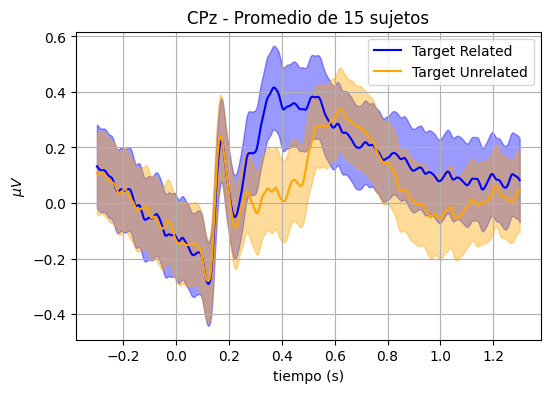

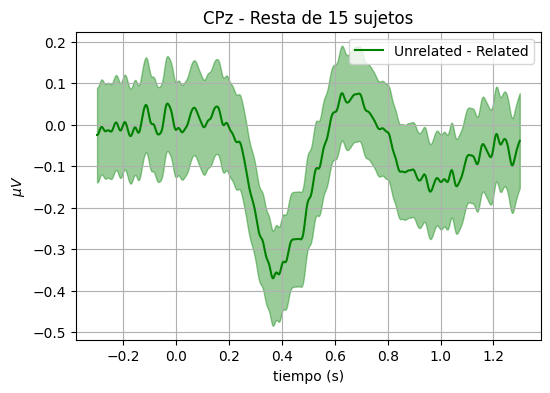

In [ ]:
y1_prom = np.mean(y1_list, axis=0)
y2_prom = np.mean(y2_list, axis=0)
y3_prom = np.mean(y3_list, axis=0)

y1std = np.array(np.std(y1_list, axis=0))
y2std = np.array(np.std(y2_list, axis=0))
y3std = np.array(np.std(y3_list, axis=0))

y1err_prom = np.sqrt(np.sum(np.square(y1std)))/np.sqrt(len(y1std))
y2err_prom = np.sqrt(np.sum(np.square(y2std)))/np.sqrt(len(y2std))
y3err_prom = np.sqrt(np.sum(np.square(y3std)))/np.sqrt(len(y3std))

y1L = y1_prom-y1err_prom
y1H = y1_prom+y1err_prom
y2L = y2_prom-y2err_prom
y2H = y2_prom+y2err_prom
y3L = y3_prom-y3err_prom
y3H = y3_prom+y3err_prom

n = len(y1_list)
plt.figure(figsize=(6,4))
plt.title('CPz - Promedio de '+ str(n) + ' sujetos')
plt.plot(tiempo,y1_prom,c='b',label='Target Related')
plt.fill_between(tiempo,y1L,y1H,color='b',alpha=0.4 )

plt.plot(tiempo,y2_prom,c='orange',label='Target Unrelated')
plt.fill_between(tiempo,y2L,y2H,color='orange',alpha=0.4 )
plt.xlabel('tiempo (s)')
plt.ylabel(r'$\mu V$')
plt.grid(True)
plt.legend()

plt.figure(figsize=(6,4))
plt.title(f'CPz - Resta de '+ str(n) + ' sujetos')
plt.plot(tiempo,y3_prom,c='g',label='Unrelated - Related')
plt.fill_between(tiempo,y3L,y3H,color='g',alpha=0.4 )
plt.grid(True)
plt.xlabel('tiempo (s)')
plt.ylabel(r'$\mu V$')
plt.legend()

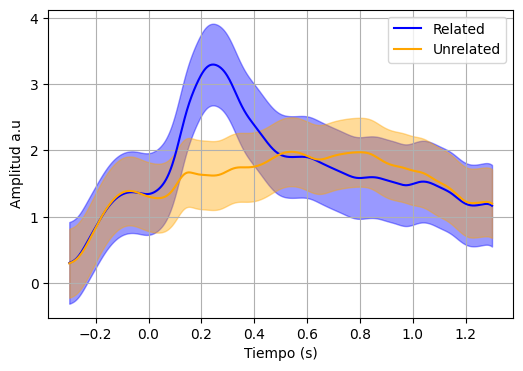

In [12]:
#analisis de frecuencia
theta_rel_prom = np.mean(theta_rel, axis=0)
theta_unrel_prom = np.mean(theta_unrel, axis=0)
unreldsv = np.std(theta_unrel, axis=0)
reldsv = np.std(theta_rel, axis=0)
theta_unrel_prom_err = np.sqrt(np.sum(np.square(unreldsv)))/np.sqrt(len(unreldsv))
theta_rel_prom_err = np.sqrt(np.sum(np.square(reldsv)))/np.sqrt(len(reldsv))

y1L = theta_rel_prom-theta_rel_prom_err
y1H = theta_rel_prom+theta_rel_prom_err
y2L = theta_unrel_prom-theta_unrel_prom_err
y2H = theta_unrel_prom+theta_unrel_prom_err

fig=plt.figure(figsize=(6,4))
plt.grid(True)
#plt.title(f'Frecs de 1 a 4 Hz - promedio de 15 sujetos')
plt.fill_between(tiempo_freq,y1L,y1H,color='blue',alpha=0.4 )
plt.fill_between(tiempo_freq,y2L,y2H,color='orange',alpha=0.4 )
plt.plot(tiempo_freq,theta_rel_prom,c='b',label='Related')
plt.plot(tiempo_freq,theta_unrel_prom,c='orange',label='Unrelated')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud a.u')
plt.legend()